In [ ]:
!wget -O names.txt https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-07-10 15:07:21--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

2026-07-10 15:07:21 (8.40 MB/s) - ‘names.txt’ saved [228145/228145]



In [ ]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
 chars = sorted(list(set(''.join(words))))
 stoi = {s:i+1 for i,s in enumerate(chars)}
 stoi['.'] = 0
 itos = {i:s for s, i in stoi.items()}
 vocab_size = len(itos)
 print(itos)
 print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [ ]:
block_size = 3
def build_dataset(words):
  X, Y = [], []
  # ...arman .
  for w in words:
    # print(w)
    context = [0]*block_size
    for ch in w+'.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:]+[ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape,Y.shape)
  return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set 80 %
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set 10 %
Xte, Yte = build_dataset(words[n2:]) # testing set 10 %

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
n_embed = 10
n_hidden = 200
# Everyhting all together
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embed), generator = g)
W1 = torch.randn((n_embed*block_size, n_hidden), generator = g) * (5/3)/((n_embed*block_size)**0.5)
b1 = torch.randn(n_hidden, generator = g) *.01
W2 = torch.randn((n_hidden, vocab_size), generator = g) * 0.01
b2 = torch.randn(vocab_size, generator = g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))

parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True
sum(p.nelement() for p in parameters)

11897

In [ ]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance (as per that Google @2015 paper)
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


n_embed = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embed), generator=g)
# we can remove this Tanh(), but that will leads to a calculated behaviour i.e. linear i/p and o/p; the the activation function help it somewhat so we can teach a
# nerual network to work on arbitary data, given we trained it. idk its jittey but for now bear this
layers = [
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]


"""
this above MLP have following

Input(30)->Layer1(100)->Tanh()->Layer2(100)->Tanh()->Layer3(100)->Tanh()->Layer4(100)->Tanh()->Layer5(100)->Tanh()->Layer6(27)

Input is 30 coz n_embed = 10 and block_size = 3 i.e. [e,m,m] -> [0.1,0.4,45,.....5.6] this single example will have 30 data point

now let say output is [e,m,m] -> [a] i.e. we can have 27 possible characters thus output as 27 (we have 0 -> '.')

"""


with torch.no_grad():
  # last layer: make less confident coz we dont want that it randomly assign high confidence an character which is not supposed to be (i.e. learning will have to make a lot of effort to correct itself)
  # conclusion: we can have smooth start in training
  layers[-1].weight *= 0.1

  # all other layers: apply gain (as Tanh() try to squash them overtime, i.e. std will come near to 0, so mathmatically calculated gain is multiplied)
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *=  5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True


46497


In [ ]:
Xtr.shape, Xtr.shape[0]

(torch.Size([182625, 3]), 182625)

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 2.2528


layer 1 (      Tanh): mean -0.03, std 0.75, saturated: 19.41%
layer 3 (      Tanh): mean -0.04, std 0.73, saturated: 14.28%
layer 5 (      Tanh): mean -0.02, std 0.75, saturated: 15.03%
layer 7 (      Tanh): mean +0.01, std 0.76, saturated: 14.72%
layer 9 (      Tanh): mean +0.09, std 0.72, saturated: 11.19%


Text(0.5, 1.0, 'activation distribution')

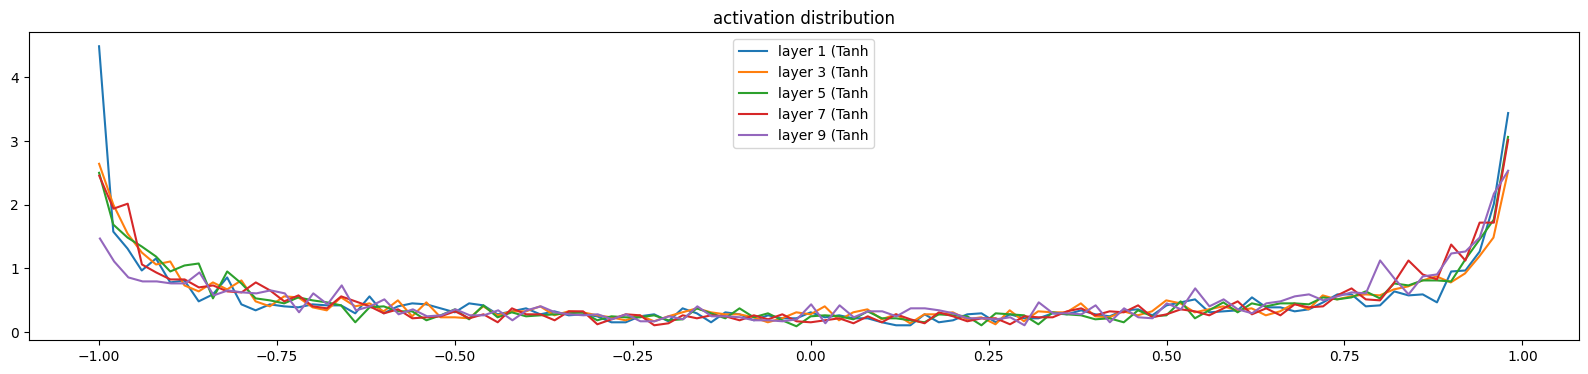

In [ ]:
# visualize forward pass histograms  ( this one help us to see in the inner tanh layers wheather they are saturated(dead) or non-saturated, high saturation will kill the neurons as there will be
# no change in weight/biases during backpropogation; so through this tool we aim to fix the saturation of out network)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 1 (      Tanh): mean -0.000031, std 2.784260e-03
layer 3 (      Tanh): mean +0.000054, std 2.626361e-03
layer 5 (      Tanh): mean +0.000094, std 2.608175e-03
layer 7 (      Tanh): mean +0.000025, std 2.720767e-03
layer 9 (      Tanh): mean -0.000098, std 2.480295e-03


Text(0.5, 1.0, 'gradient distribution')

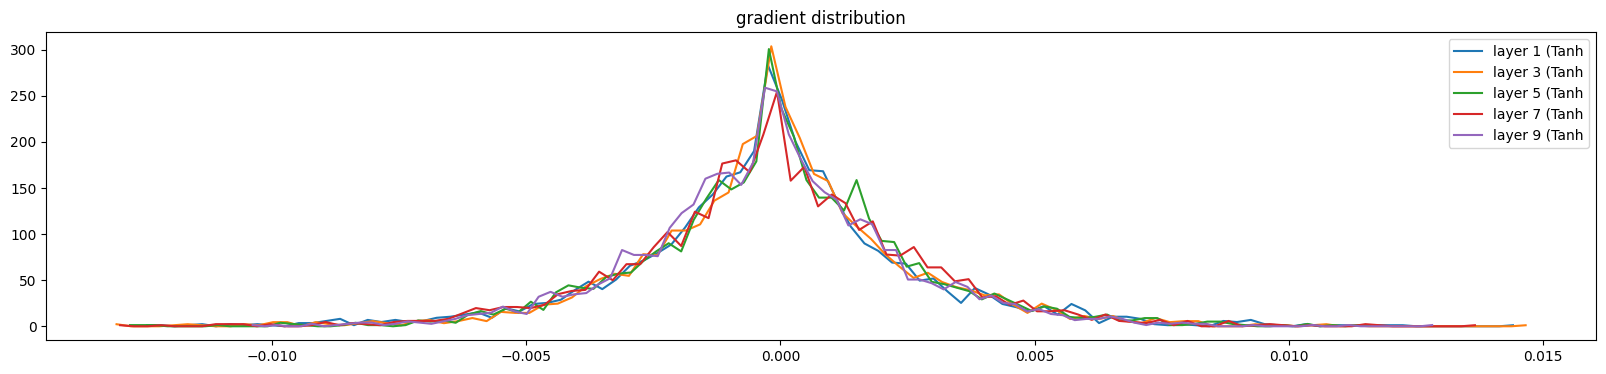

In [ ]:
# visualize backword pass histograms (this one help us to figure out that our gradients are travelling roughly at same pattern thorought out the layers, as diffrent setting may lead to die out
# of these gradient / or explode it)
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000692 | std 1.098980e-02 | grad:data ratio 1.093125e-02
weight  (30, 100) | mean -0.000055 | std 8.855228e-03 | grad:data ratio 2.952931e-02
weight (100, 100) | mean -0.000091 | std 6.646686e-03 | grad:data ratio 3.876251e-02
weight (100, 100) | mean +0.000052 | std 6.353266e-03 | grad:data ratio 3.743842e-02
weight (100, 100) | mean -0.000060 | std 6.754149e-03 | grad:data ratio 4.000683e-02
weight (100, 100) | mean +0.000011 | std 6.420746e-03 | grad:data ratio 3.828657e-02
weight  (100, 27) | mean -0.000000 | std 2.409022e-02 | grad:data ratio 2.927125e-01


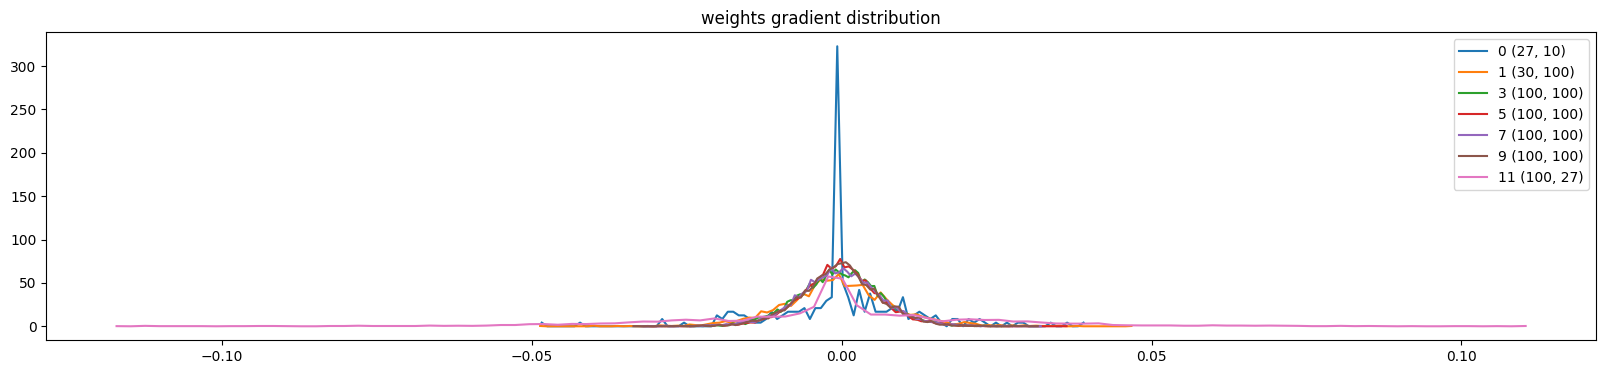

In [ ]:
# visualize histograms (# this can usefull for observing the learning rate [how much we are adjusting the weights, we have to figure out best learning rate )
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

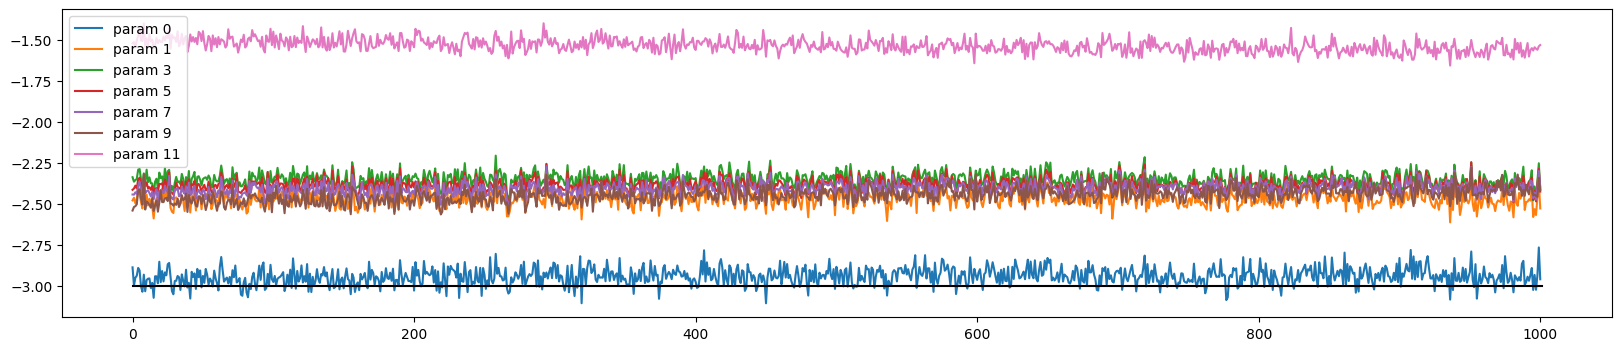

In [ ]:
# this can usefull for observing the learning rate [how much we are adjusting the weights, we have to figure out best learning rate )
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [ ]:
# lr = torch.linspace(0.001,1,1000) #learning rate
# lre = torch.linspace(-3,0,1000) #learning rate exponent
# lrs = 10**lre # actual learning rates
# lri = []

max_steps = 200000
batch_size = 32
lossi = []
stepi = []
for i in range(max_steps):

  # mini batch
  ix = torch.randint(0,Xtr.shape[0],(batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  #forward pass
  emb  = C[Xb] #(32,3,2)
  embcat = emb.view(emb.shape[0],-1) #(32,6)
  hpreact = embcat @ W1 + b1 #(32,100)
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)
  hpreact = bngain*(hpreact - bnmean) / bnstd + bnbias #(32,100)

  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmean
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstd

  h = torch.tanh(hpreact) #(32,100)
  logits = h @ W2 + b2 #(32,27)
  # counts = logits.exp()
  # prob = counts/counts.sum(1, keepdims = True)
  # loss = - prob[torch.arange(32),Y].log().mean()
  # replacign above by cross_entropy as
  loss = F.cross_entropy(logits,Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # nudge the weights such that we are minimizing the loss or going in negative gradient direction hehe
  # lr = lrs[i]
  lr = 0.1 if i<10000 else 0.01 # we found form the graph the optimal learning rate
  for p in parameters:
    p.data += -1*lr*p.grad

  stepi.append(i)
  # lri.append(lre[i])
  lossi.append(loss.log10().item())

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  break


TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

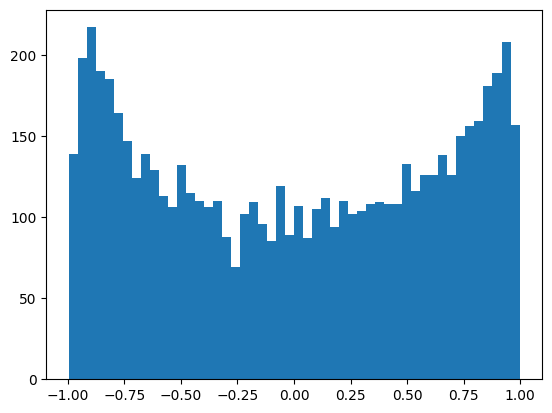

In [ ]:
plt.hist(h.view(-1).tolist(),50);

In [ ]:
plt.hist(hpreact.view(-1).tolist(),50);

In [ ]:
plt.plot(lossi)

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation="nearest")

In [ ]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation="nearest")

In [ ]:
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


In [ ]:
plt.plot(stepi,lossi)

In [ ]:
sum(p.nelement() for p in parameters)

In [ ]:

# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))